In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from src.knn import KNN
from src.metrics import accuracy,recall,precision,f1_score,roc_auc
from src.splits import stratified_split
#ayirmadim cunki mende problem olurdu pymda
np.random.seed(42)
df=pd.read_csv('../data/titanic3.csv')

df['age']=df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

df['sex'] = df['sex'].map({'male': 1, 'female': 0})
df = pd.get_dummies(df, columns=['embarked'], drop_first=False)
df['embarked_C'] = df['embarked_C'].astype(int)
df['embarked_Q'] = df['embarked_Q'].astype(int)
df['embarked_S'] = df['embarked_S'].astype(int)
df.head()
df.columns.tolist()

['pclass',
 'survived',
 'name',
 'sex',
 'age',
 'sibsp',
 'parch',
 'ticket',
 'fare',
 'cabin',
 'boat',
 'body',
 'home.dest',
 'embarked_C',
 'embarked_Q',
 'embarked_S']

In [5]:
cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 
        'embarked_C', 'embarked_Q', 'embarked_S']

X = df[cols].values
y = df['survived'].values

X_train, X_val, X_test, y_train, y_val, y_test = stratified_split(X, y, seed=42)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (785, 9), Val: (261, 9), Test: (263, 9)


In [6]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31, 51]
#sweep edirik yeniki yoxlayiriq knn imizi 
results = []
for k in k_values:
    model = KNN(k=k, metric='euclidean')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_score = model.predict_proba(X_val)[:, 1]
    
    results.append({
        'k': k,
        'accuracy': accuracy(y_val, y_pred),
        'precision': precision(y_val, y_pred),
        'recall': recall(y_val, y_pred),
        'f1': f1_score(y_val, y_pred),
        'roc_auc': roc_auc(y_val, y_score)
    })

results_df = pd.DataFrame(results)
print(results_df)


    k  accuracy  precision  recall        f1   roc_auc
0   1  0.662835   0.566667    0.51  0.536842  0.633882
1   3  0.689655   0.606742    0.54  0.571429  0.710373
2   5  0.685824   0.609756    0.50  0.549451  0.704720
3   7  0.712644   0.647059    0.55  0.594595  0.704286
4   9  0.697318   0.620690    0.54  0.577540  0.711584
5  11  0.701149   0.634146    0.52  0.571429  0.724969
6  15  0.716475   0.680556    0.49  0.569767  0.712826
7  21  0.743295   0.746269    0.50  0.598802  0.716863
8  31  0.735632   0.724638    0.50  0.591716  0.728602
9  51  0.735632   0.746032    0.47  0.576687  0.726056


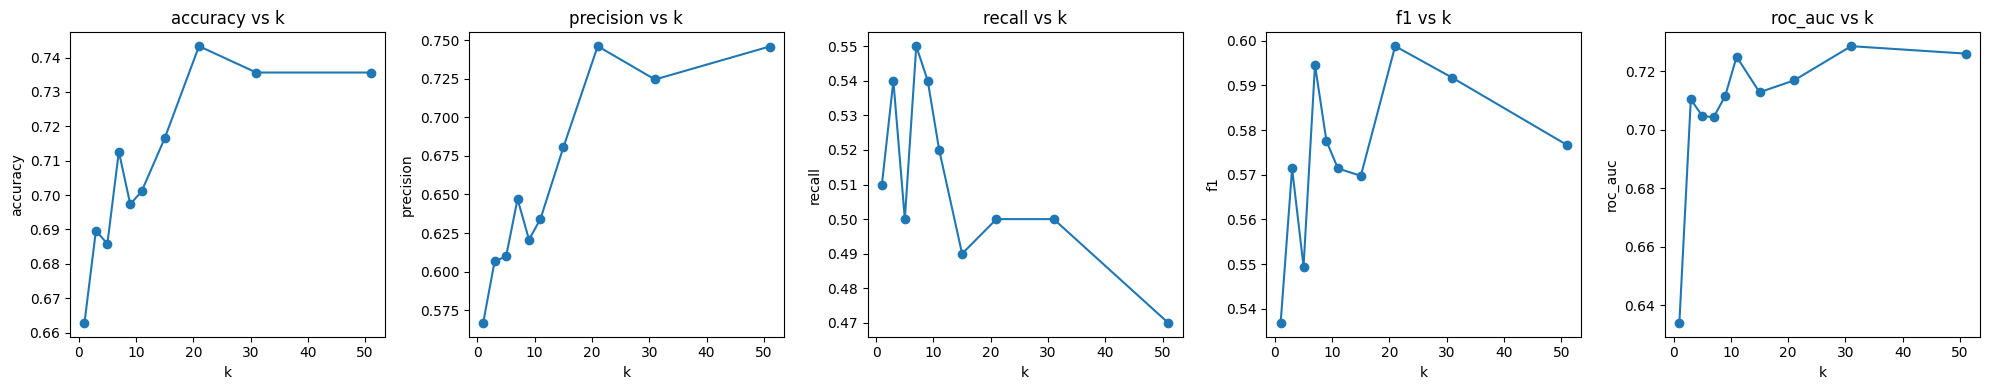

In [7]:
metrics_list = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, metric in zip(axes, metrics_list):
    ax.plot(results_df['k'], results_df[metric], marker='o')
    ax.set_xlabel('k')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} vs k')

plt.tight_layout()
plt.savefig('../figures/k_sweep.pdf')
plt.show()

In [8]:
# majority classifier
y_majority = np.zeros(len(y_val), dtype=int)  # hamısına 0 de

# en axmaq modelden yeniki baselindan yaxsidirsa demeli at least nese oyrenib

print("Majority Classifier:")
print(f"accuracy:  {accuracy(y_val, y_majority):.4f}")
print(f"precision: {precision(y_val, y_majority):.4f}")
print(f"recall:    {recall(y_val, y_majority):.4f}")
print(f"f1:        {f1_score(y_val, y_majority):.4f}")

Majority Classifier:
accuracy:  0.6169
precision: 0.0000
recall:    0.0000
f1:        0.0000


In [11]:
from sklearn.neighbors import KNeighborsClassifier

best_k = 21

# 2. Senin KNN-in
my_knn = KNN(k=best_k, metric='euclidean')
my_knn.fit(X_train, y_train)
y_pred_my = my_knn.predict(X_val)
y_score_my = my_knn.predict_proba(X_val)[:, 1]

# 3. Sklearn KNN
sk_knn = KNeighborsClassifier(n_neighbors=best_k)
sk_knn.fit(X_train, y_train)
y_pred_sk = sk_knn.predict(X_val)
y_score_sk = sk_knn.predict_proba(X_val)[:, 1]

print("\n=== My KNN (k=21) ===")
print(f"accuracy:  {accuracy(y_val, y_pred_my):.4f}")
print(f"precision: {precision(y_val, y_pred_my):.4f}")
print(f"recall:    {recall(y_val, y_pred_my):.4f}")
print(f"f1:        {f1_score(y_val, y_pred_my):.4f}")
print(f"roc_auc:   {roc_auc(y_val, y_score_my):.4f}")

print("\n=== Sklearn KNN (k=21) ===")
print(f"accuracy:  {accuracy(y_val, y_pred_sk):.4f}")
print(f"precision: {precision(y_val, y_pred_sk):.4f}")
print(f"recall:    {recall(y_val, y_pred_sk):.4f}")
print(f"f1:        {f1_score(y_val, y_pred_sk):.4f}")
print(f"roc_auc:   {roc_auc(y_val, y_score_sk):.4f}")


=== My KNN (k=21) ===
accuracy:  0.7433
precision: 0.7463
recall:    0.5000
f1:        0.5988
roc_auc:   0.7169

=== Sklearn KNN (k=21) ===
accuracy:  0.7433
precision: 0.7463
recall:    0.5000
f1:        0.5988
roc_auc:   0.7173


In [12]:
print("Final Test Set Evaluation (k=21)")
y_pred_test = my_knn.predict(X_test)
y_score_test = my_knn.predict_proba(X_test)[:, 1]

print(f"accuracy:  {accuracy(y_test, y_pred_test):.4f}")
print(f"precision: {precision(y_test, y_pred_test):.4f}")
print(f"recall:    {recall(y_test, y_pred_test):.4f}")
print(f"f1:        {f1_score(y_test, y_pred_test):.4f}")
print(f"roc_auc:   {roc_auc(y_test, y_score_test):.4f}")

=== Final Test Set Evaluation (k=21) ===
accuracy:  0.6730
precision: 0.5875
recall:    0.4700
f1:        0.5222
roc_auc:   0.7349
